# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Anthropic | Google | Human | Meta | OpenAI

## 0. Setup — Imports e Configuração

In [1]:
import sys
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

[pytorch_models] Using device: cpu
PyTorch version: 2.10.0
Device: cpu


In [2]:
# Hiperparâmetros 

CLASSES       = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 2000     # tamanho do vocabulário TF-IDF
MAX_LEN       = 150      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 10000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 128      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 10       # early stopping

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

Total de exemplos: 4927

Distribuição por classe:


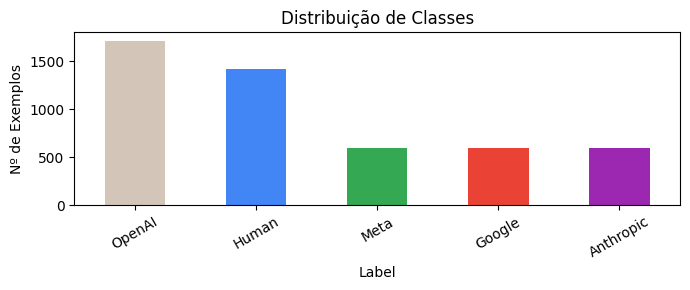

In [3]:
# Carregar dataset
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos: {len(texts)}")
print("\nDistribuição por classe:")
df['Label'].value_counts().plot(kind='bar', color=['#D4C5B9', '#4285F4', '#34A853', '#EA4335', '#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [4]:
# Split treino / validação / teste
X_tr, X_te, y_tr, y_te = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE, stratify=y_tr)

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste:     {len(X_te)} exemplos")

Treino:    3448 exemplos
Validação: 493 exemplos
Teste:     986 exemplos


In [5]:
# Datasets TF-IDF (para Baseline e DNN) 
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU) 
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")

Vocabulário (Embeddings): 10002 palavras


## Funções de Visualização

In [6]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [7]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...


Epoch 1/100 | train_loss: 1.5132 | train_acc: 0.5629 | val_loss: 1.5204 | val_acc: 0.5477
Epoch 2/100 | train_loss: 1.4381 | train_acc: 0.5835 | val_loss: 1.4523 | val_acc: 0.5700
Epoch 3/100 | train_loss: 1.3736 | train_acc: 0.5969 | val_loss: 1.3953 | val_acc: 0.5781
Epoch 4/100 | train_loss: 1.3176 | train_acc: 0.6012 | val_loss: 1.3462 | val_acc: 0.5842
Epoch 5/100 | train_loss: 1.2672 | train_acc: 0.6085 | val_loss: 1.3023 | val_acc: 0.5862
Epoch 6/100 | train_loss: 1.2212 | train_acc: 0.6169 | val_loss: 1.2629 | val_acc: 0.5923
Epoch 7/100 | train_loss: 1.1787 | train_acc: 0.6253 | val_loss: 1.2264 | val_acc: 0.5943
Epoch 8/100 | train_loss: 1.1388 | train_acc: 0.6407 | val_loss: 1.1925 | val_acc: 0.5963


Epoch 9/100 | train_loss: 1.1011 | train_acc: 0.6624 | val_loss: 1.1606 | val_acc: 0.6105
Epoch 10/100 | train_loss: 1.0660 | train_acc: 0.6850 | val_loss: 1.1307 | val_acc: 0.6207
Epoch 11/100 | train_loss: 1.0322 | train_acc: 0.7045 | val_loss: 1.1025 | val_acc: 0.6308
Epoch 12/100 | train_loss: 1.0005 | train_acc: 0.7230 | val_loss: 1.0757 | val_acc: 0.6450
Epoch 13/100 | train_loss: 0.9705 | train_acc: 0.7433 | val_loss: 1.0503 | val_acc: 0.6633
Epoch 14/100 | train_loss: 0.9418 | train_acc: 0.7680 | val_loss: 1.0262 | val_acc: 0.6775
Epoch 15/100 | train_loss: 0.9141 | train_acc: 0.7860 | val_loss: 1.0033 | val_acc: 0.6856
Epoch 16/100 | train_loss: 0.8882 | train_acc: 0.8019 | val_loss: 0.9815 | val_acc: 0.6917


Epoch 17/100 | train_loss: 0.8632 | train_acc: 0.8132 | val_loss: 0.9608 | val_acc: 0.7120
Epoch 18/100 | train_loss: 0.8394 | train_acc: 0.8263 | val_loss: 0.9411 | val_acc: 0.7262
Epoch 19/100 | train_loss: 0.8168 | train_acc: 0.8382 | val_loss: 0.9222 | val_acc: 0.7424
Epoch 20/100 | train_loss: 0.7950 | train_acc: 0.8503 | val_loss: 0.9042 | val_acc: 0.7606
Epoch 21/100 | train_loss: 0.7742 | train_acc: 0.8596 | val_loss: 0.8870 | val_acc: 0.7708
Epoch 22/100 | train_loss: 0.7544 | train_acc: 0.8680 | val_loss: 0.8705 | val_acc: 0.7769
Epoch 23/100 | train_loss: 0.7352 | train_acc: 0.8759 | val_loss: 0.8548 | val_acc: 0.7809
Epoch 24/100 | train_loss: 0.7169 | train_acc: 0.8840 | val_loss: 0.8396 | val_acc: 0.7850


Epoch 25/100 | train_loss: 0.6990 | train_acc: 0.8915 | val_loss: 0.8251 | val_acc: 0.7890
Epoch 26/100 | train_loss: 0.6822 | train_acc: 0.8991 | val_loss: 0.8112 | val_acc: 0.7951
Epoch 27/100 | train_loss: 0.6659 | train_acc: 0.9052 | val_loss: 0.7978 | val_acc: 0.8012
Epoch 28/100 | train_loss: 0.6502 | train_acc: 0.9092 | val_loss: 0.7848 | val_acc: 0.8073
Epoch 29/100 | train_loss: 0.6351 | train_acc: 0.9136 | val_loss: 0.7723 | val_acc: 0.8154
Epoch 30/100 | train_loss: 0.6205 | train_acc: 0.9159 | val_loss: 0.7605 | val_acc: 0.8174
Epoch 31/100 | train_loss: 0.6065 | train_acc: 0.9197 | val_loss: 0.7489 | val_acc: 0.8235
Epoch 32/100 | train_loss: 0.5927 | train_acc: 0.9255 | val_loss: 0.7379 | val_acc: 0.8276


...

Epoch 73/100 | train_loss: 0.2751 | train_acc: 0.9832 | val_loss: 0.4796 | val_acc: 0.8803
Epoch 74/100 | train_loss: 0.2708 | train_acc: 0.9843 | val_loss: 0.4760 | val_acc: 0.8803
Epoch 75/100 | train_loss: 0.2665 | train_acc: 0.9846 | val_loss: 0.4725 | val_acc: 0.8803
Epoch 76/100 | train_loss: 0.2622 | train_acc: 0.9855 | val_loss: 0.4690 | val_acc: 0.8803
Epoch 77/100 | train_loss: 0.2580 | train_acc: 0.9855 | val_loss: 0.4657 | val_acc: 0.8803
Epoch 78/100 | train_loss: 0.2540 | train_acc: 0.9867 | val_loss: 0.4626 | val_acc: 0.8803
Epoch 79/100 | train_loss: 0.2500 | train_acc: 0.9867 | val_loss: 0.4593 | val_acc: 0.8803


Epoch 80/100 | train_loss: 0.2463 | train_acc: 0.9872 | val_loss: 0.4561 | val_acc: 0.8803
Epoch 81/100 | train_loss: 0.2423 | train_acc: 0.9881 | val_loss: 0.4530 | val_acc: 0.8803
Epoch 82/100 | train_loss: 0.2386 | train_acc: 0.9881 | val_loss: 0.4500 | val_acc: 0.8803
Epoch 83/100 | train_loss: 0.2349 | train_acc: 0.9887 | val_loss: 0.4470 | val_acc: 0.8803
Epoch 84/100 | train_loss: 0.2314 | train_acc: 0.9890 | val_loss: 0.4442 | val_acc: 0.8783
Epoch 85/100 | train_loss: 0.2278 | train_acc: 0.9890 | val_loss: 0.4413 | val_acc: 0.8783


Epoch 86/100 | train_loss: 0.2244 | train_acc: 0.9893 | val_loss: 0.4386 | val_acc: 0.8783
Epoch 87/100 | train_loss: 0.2209 | train_acc: 0.9893 | val_loss: 0.4358 | val_acc: 0.8783
Epoch 88/100 | train_loss: 0.2175 | train_acc: 0.9898 | val_loss: 0.4332 | val_acc: 0.8783
Epoch 89/100 | train_loss: 0.2143 | train_acc: 0.9901 | val_loss: 0.4305 | val_acc: 0.8783
Epoch 90/100 | train_loss: 0.2111 | train_acc: 0.9910 | val_loss: 0.4279 | val_acc: 0.8783
Epoch 91/100 | train_loss: 0.2080 | train_acc: 0.9913 | val_loss: 0.4254 | val_acc: 0.8803
Epoch 92/100 | train_loss: 0.2049 | train_acc: 0.9916 | val_loss: 0.4228 | val_acc: 0.8803


Epoch 93/100 | train_loss: 0.2019 | train_acc: 0.9919 | val_loss: 0.4203 | val_acc: 0.8824
Epoch 94/100 | train_loss: 0.1989 | train_acc: 0.9922 | val_loss: 0.4181 | val_acc: 0.8824
Epoch 95/100 | train_loss: 0.1959 | train_acc: 0.9922 | val_loss: 0.4158 | val_acc: 0.8783
Epoch 96/100 | train_loss: 0.1931 | train_acc: 0.9925 | val_loss: 0.4134 | val_acc: 0.8803
Epoch 97/100 | train_loss: 0.1902 | train_acc: 0.9930 | val_loss: 0.4112 | val_acc: 0.8803
Epoch 98/100 | train_loss: 0.1874 | train_acc: 0.9930 | val_loss: 0.4089 | val_acc: 0.8803
Epoch 99/100 | train_loss: 0.1848 | train_acc: 0.9933 | val_loss: 0.4068 | val_acc: 0.8824


Epoch 100/100 | train_loss: 0.1820 | train_acc: 0.9939 | val_loss: 0.4047 | val_acc: 0.8824


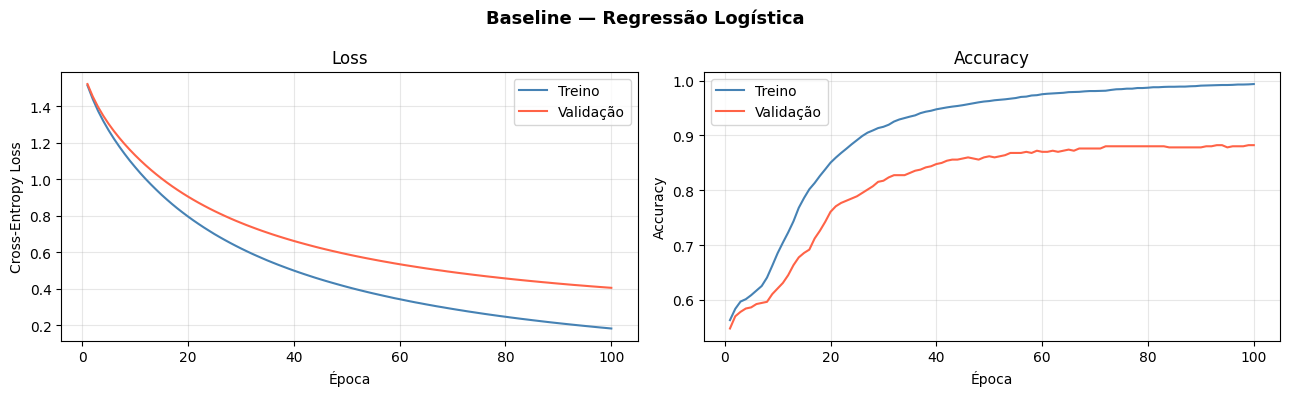


Accuracy no Teste (Baseline): 87.83%


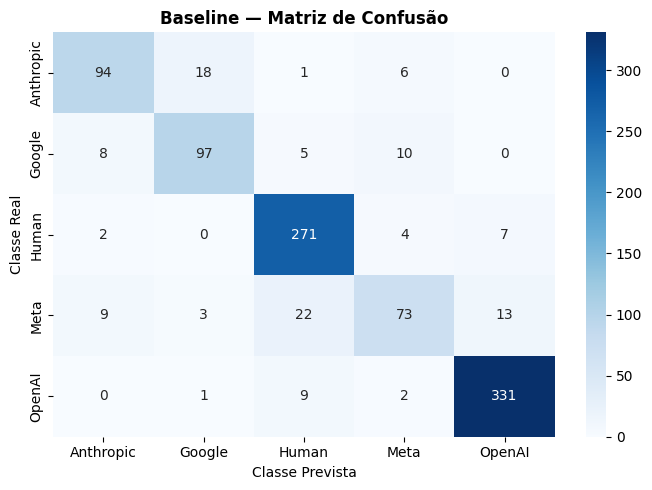

              precision    recall  f1-score   support

   Anthropic       0.83      0.79      0.81       119
      Google       0.82      0.81      0.81       120
       Human       0.88      0.95      0.92       284
        Meta       0.77      0.61      0.68       120
      OpenAI       0.94      0.97      0.95       343

    accuracy                           0.88       986
   macro avg       0.85      0.83      0.83       986
weighted avg       0.87      0.88      0.87       986



In [8]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [9]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar DNN (TF-IDF)...


Epoch 1/100 | train_loss: 1.0783 | train_acc: 0.4762 | val_loss: 1.0946 | val_acc: 0.4625


Epoch 2/100 | train_loss: 0.4998 | train_acc: 0.7610 | val_loss: 0.5780 | val_acc: 0.7424
Epoch 3/100 | train_loss: 0.3496 | train_acc: 0.8405 | val_loss: 0.4761 | val_acc: 0.7992


Epoch 4/100 | train_loss: 0.2358 | train_acc: 0.8889 | val_loss: 0.4336 | val_acc: 0.8235


Epoch 5/100 | train_loss: 0.1867 | train_acc: 0.9310 | val_loss: 0.4490 | val_acc: 0.8235


...

Epoch 9/100 | train_loss: 0.0081 | train_acc: 0.9997 | val_loss: 0.4708 | val_acc: 0.8722


Epoch 10/100 | train_loss: 0.0054 | train_acc: 1.0000 | val_loss: 0.4979 | val_acc: 0.8722
Epoch 11/100 | train_loss: 0.0022 | train_acc: 1.0000 | val_loss: 0.5809 | val_acc: 0.8600


Epoch 12/100 | train_loss: 0.0033 | train_acc: 0.9997 | val_loss: 0.5457 | val_acc: 0.8803
Epoch 13/100 | train_loss: 0.0014 | train_acc: 1.0000 | val_loss: 0.5320 | val_acc: 0.8884
Epoch 14/100 | train_loss: 0.0027 | train_acc: 0.9997 | val_loss: 0.5696 | val_acc: 0.8783


Epoch 15/100 | train_loss: 0.0009 | train_acc: 0.9997 | val_loss: 0.5688 | val_acc: 0.8702
Epoch 16/100 | train_loss: 0.0011 | train_acc: 0.9997 | val_loss: 0.5927 | val_acc: 0.8742


Epoch 17/100 | train_loss: 0.0025 | train_acc: 0.9994 | val_loss: 0.5754 | val_acc: 0.8783

[Early Stopping] Stopped at epoch 17. Best val_loss: 0.4216


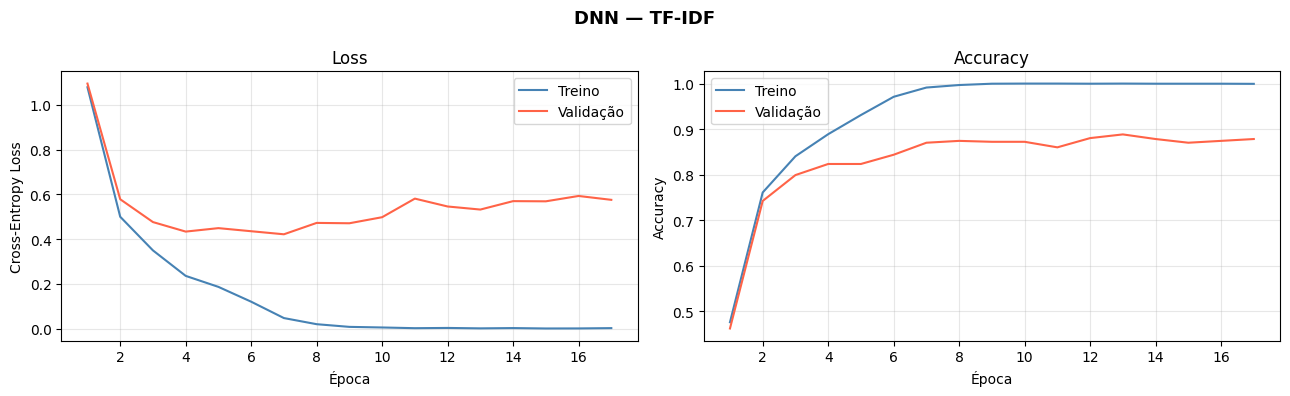


Accuracy no Teste (DNN): 87.83%


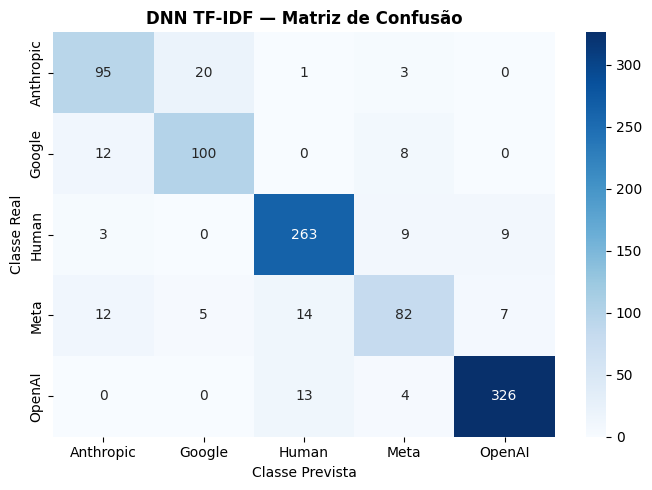

              precision    recall  f1-score   support

   Anthropic       0.78      0.80      0.79       119
      Google       0.80      0.83      0.82       120
       Human       0.90      0.93      0.91       284
        Meta       0.77      0.68      0.73       120
      OpenAI       0.95      0.95      0.95       343

    accuracy                           0.88       986
   macro avg       0.84      0.84      0.84       986
weighted avg       0.88      0.88      0.88       986



In [10]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [11]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(lstm, train_loader_seq, val_loader_seq, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiLSTM (Embeddings)...


Epoch 1/100 | train_loss: 0.8387 | train_acc: 0.6940 | val_loss: 0.8944 | val_acc: 0.6613


Epoch 2/100 | train_loss: 0.6353 | train_acc: 0.7456 | val_loss: 0.6843 | val_acc: 0.7160


Epoch 3/100 | train_loss: 0.5636 | train_acc: 0.7834 | val_loss: 0.7751 | val_acc: 0.7201


Epoch 4/100 | train_loss: 0.4493 | train_acc: 0.8347 | val_loss: 0.7053 | val_acc: 0.7221


...

Epoch 14/100 | train_loss: 0.0142 | train_acc: 0.9965 | val_loss: 0.6819 | val_acc: 0.8398


Epoch 15/100 | train_loss: 0.0066 | train_acc: 0.9988 | val_loss: 0.6568 | val_acc: 0.8519


Epoch 16/100 | train_loss: 0.0064 | train_acc: 0.9988 | val_loss: 0.6846 | val_acc: 0.8479


Epoch 17/100 | train_loss: 0.0056 | train_acc: 0.9991 | val_loss: 0.6702 | val_acc: 0.8499


Epoch 18/100 | train_loss: 0.0039 | train_acc: 0.9991 | val_loss: 0.6824 | val_acc: 0.8540

[Early Stopping] Stopped at epoch 18. Best val_loss: 0.5087


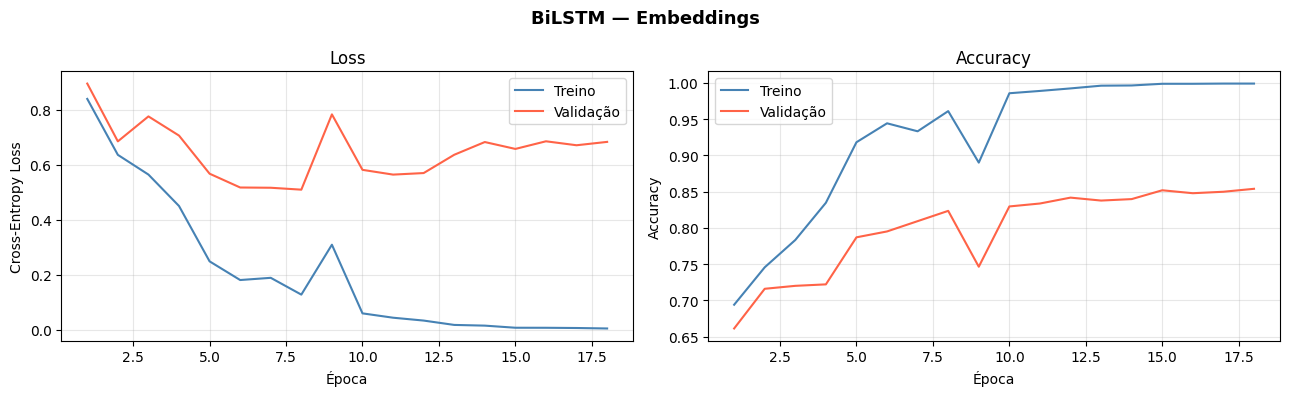


Accuracy no Teste (BiLSTM): 79.41%


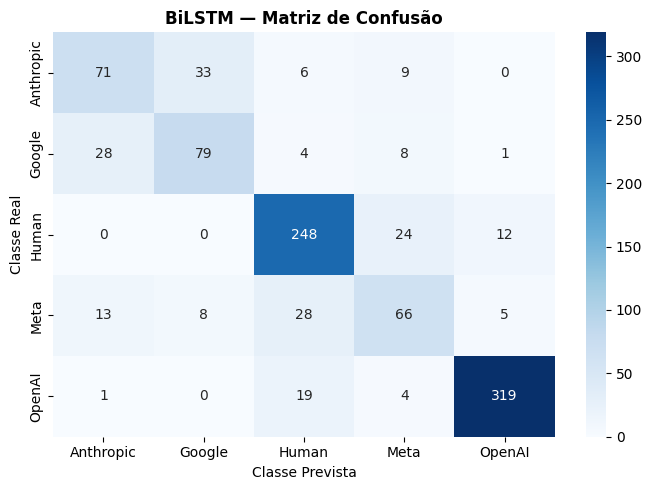

              precision    recall  f1-score   support

   Anthropic       0.63      0.60      0.61       119
      Google       0.66      0.66      0.66       120
       Human       0.81      0.87      0.84       284
        Meta       0.59      0.55      0.57       120
      OpenAI       0.95      0.93      0.94       343

    accuracy                           0.79       986
   macro avg       0.73      0.72      0.72       986
weighted avg       0.79      0.79      0.79       986



In [12]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [13]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(gru, train_loader_seq, val_loader_seq, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiGRU (Embeddings)...


Epoch 1/100 | train_loss: 0.8773 | train_acc: 0.6818 | val_loss: 0.9151 | val_acc: 0.6511


Epoch 2/100 | train_loss: 0.4888 | train_acc: 0.8106 | val_loss: 0.5988 | val_acc: 0.7485


Epoch 3/100 | train_loss: 0.3629 | train_acc: 0.8683 | val_loss: 0.5326 | val_acc: 0.7789


Epoch 4/100 | train_loss: 0.2071 | train_acc: 0.9278 | val_loss: 0.4868 | val_acc: 0.8235


...

Epoch 11/100 | train_loss: 0.0223 | train_acc: 0.9942 | val_loss: 0.6638 | val_acc: 0.8276


Epoch 12/100 | train_loss: 0.0083 | train_acc: 0.9985 | val_loss: 0.6642 | val_acc: 0.8215


Epoch 13/100 | train_loss: 0.0053 | train_acc: 0.9991 | val_loss: 0.6873 | val_acc: 0.8377


Epoch 14/100 | train_loss: 0.0096 | train_acc: 0.9977 | val_loss: 0.7243 | val_acc: 0.8276


Epoch 15/100 | train_loss: 0.0095 | train_acc: 0.9977 | val_loss: 0.6906 | val_acc: 0.8418

[Early Stopping] Stopped at epoch 15. Best val_loss: 0.4455


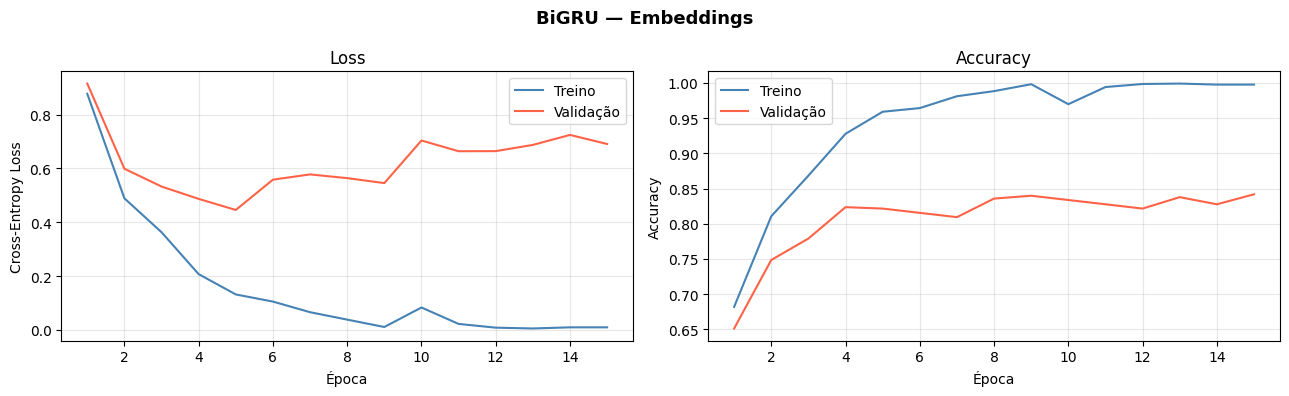


Accuracy no Teste (BiGRU): 81.14%


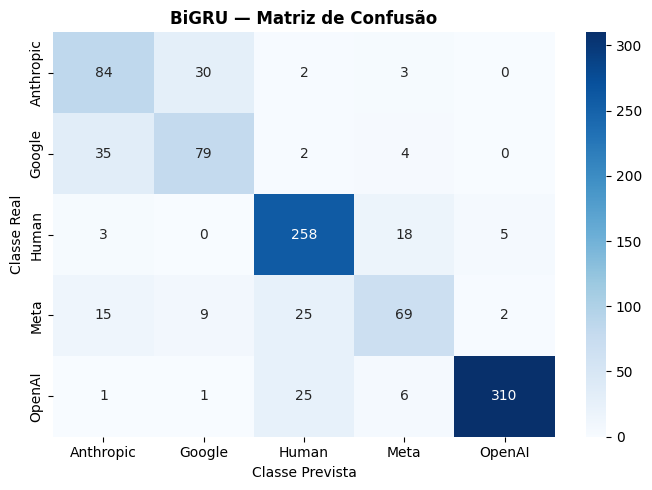

              precision    recall  f1-score   support

   Anthropic       0.61      0.71      0.65       119
      Google       0.66      0.66      0.66       120
       Human       0.83      0.91      0.87       284
        Meta       0.69      0.57      0.63       120
      OpenAI       0.98      0.90      0.94       343

    accuracy                           0.81       986
   macro avg       0.75      0.75      0.75       986
weighted avg       0.82      0.81      0.81       986



In [14]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos


 COMPARAÇÃO DE MODELOS — Accuracy no Teste
  Baseline (LogReg)      87.83%  ███████████████████████████████████
  DNN (TF-IDF)           87.83%  ███████████████████████████████████
  BiGRU                  81.14%  ████████████████████████████████
  BiLSTM                 79.41%  ███████████████████████████████


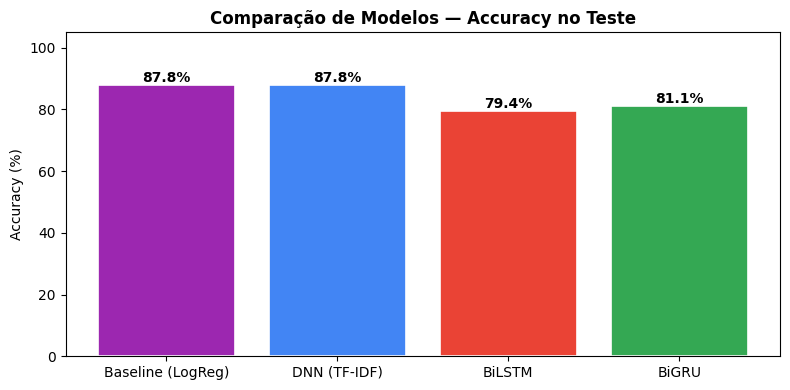

In [15]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [16]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

Modelos guardados em: ../models/pytorch_models/saved_models


---
## 8. Carregar e Usar um Modelo Guardado

In [17]:
# Exemplo: carregar o DNN e classifcar um texto novo
model_loaded = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_loaded.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', weights_only=True))
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)

Classe prevista: Human
Probabilidades:
  Anthropic    0.0%  
  Google       0.0%  
  Human       99.4%  █████████████████████████████
  Meta         0.3%  
  OpenAI       0.3%  


'Human'

---
## 9. Gerar Ficheiro de Submissão B (PyTorch)

Este passo lê o ficheiro `subm1.csv`, que contém apenas os textos de teste sem labels, carrega um dos modelos PyTorch treinados (neste caso, o **DNN**) e prevê a classe para cada texto. O resultado é depois exportado para `Subm1/subm1-g3-MIA-B.csv`.

In [18]:
import os
import pandas as pd
import torch

# 1. Ler o ficheiro de teste
subm_path = '../subm1.csv'
df_subm = pd.read_csv(subm_path, sep=';')

# 2. Certificar que a classe 'Mistral' foi removida das features de teste
# Transformar os textos usando o vectorizer TF-IDF já ajustado (train_ds_tfidf)
X_subm_tfidf = train_ds_tfidf.vectorizer.transform(df_subm['Text']).toarray()

# 3. Carregar o modelo guardado (DNN é o mais robusto do TF-IDF em Accuracy)
model_subm = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_subm.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', map_location=torch.device('cpu'), weights_only=True))
model_subm.eval()

# 4. Fazer predições
X_subm_tensor = torch.tensor(X_subm_tfidf, dtype=torch.float32)
with torch.no_grad():
    logits_subm = model_subm(X_subm_tensor)
    probs_subm = torch.softmax(logits_subm, dim=1)
    preds_idx = probs_subm.argmax(dim=1).numpy()

# 5. Mapear os indíces para as labels correspondentes
predicted_labels = [idx2label[idx] for idx in preds_idx]

# 6. Criar o DataFrame final
df_final_b = pd.DataFrame({
    'ID': df_subm['ID'],
    'Text': df_subm['Text'],
    'Label': predicted_labels
})

# 7. Guardar no diretório Subm1
output_dir = '../Subm1'
os.makedirs(output_dir, exist_ok=True)
output_filename = os.path.join(output_dir, 'subm1-g3-MIA-B.csv')

df_final_b.to_csv(output_filename, sep=';', index=False)

print(f"Ficheiro de submissão criado com sucesso: {output_filename}")
print(df_final_b.head())


Ficheiro de submissão criado com sucesso: ../Subm1/subm1-g3-MIA-B.csv
     ID                                               Text   Label
0  D2-1  A covalent bond is a chemical bond that involv...    Meta
1  D2-2  A covalent bond forms when two atoms share one...   Human
2  D2-3  A covalent bond is a type of chemical bond whe...   Human
3  D2-4  A covalent bond is a chemical bond that involv...  OpenAI
4  D2-5  Driven by exciting developments in the field o...  OpenAI
